In [1]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from pathlib import Path
import glob
from ase.io import read, write
from ase.build import make_supercell
import numpy as np

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

P = np.array([0.0, 0.1, 0.2, 0.3, 0.4, 0.5])
# Simulació (Ast)
S_sim= np.array([
    607.63,
    635.44,
    623.72,
    626.94,
    605.52,
    621.26
])
	
# Entalpia (Ash)

S_H= np.array([
    441.68,
    534.65,
    522.35,
    521.35,
    491.08,
    519.20
])

# Experimental
# A P=0 tens dues mesures (475 i 544)
S_exp = np.array([
    475 ,
    473.00,
    468.00,
    np.nan,
    np.nan,
    np.nan
])

S_exp2 = np.array([
    543.8 ,
    np.nan,
    np.nan,
    np.nan,
    np.nan,
    np.nan
])


err_exp = 0.15 * S_exp
err_H = np.full(len(P), 10.0)
err_sim = np.full(len(P), 50.0)

plt.figure(figsize=(8,6))

plt.errorbar(
    P, S_sim, yerr=err_sim,
    fmt='o', capsize=4,
    label='Simulació'
)

plt.errorbar(
    P, S_H, yerr=err_H,
    fmt='^', capsize=4,
    label='Entalpia'
)

plt.errorbar(
    P, S_exp, yerr=err_exp,
    fmt='s', capsize=4,
    label='Experimental 1'
)

plt.errorbar(
    P, S_exp2, yerr=0,
    fmt='^', capsize=4,
    label='Experimental 2'
)





plt.xlabel('Pressió (MPa)')
plt.ylabel(r'$\Delta S$ (J mol$^{-1}$ K$^{-1}$)')
plt.title(r'$\Delta S$ en funció de la pressió')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
P = np.array([0.0, 0.1, 0.2, 0.3, 0.4, 0.5])
# Simulació (Ast)
S_sim= np.array([
    607.63,
    635.44,
    623.72,
    626.94,
    605.52,
    621.26
])
	
# Entalpia (Ash)

S_H= np.array([
    441.68,
    534.65,
    522.35,
    521.35,
    491.08,
    519.20
])

# Experimental
# A P=0 tens dues mesures (475 i 544)
S_exp = np.array([
    475 ,
    473.00,
    468.00,
    np.nan,
    np.nan,
    np.nan
])

S_exp2 = np.array([
    543.8 ,
    np.nan,
    np.nan,
    np.nan,
    np.nan,
    np.nan
])


err_exp = 0.15 * S_exp
err_H = np.full(len(P), 10.0)
err_sim = np.full(len(P), 50.0)

plt.figure(figsize=(8,6))

plt.errorbar(
    P, S_sim, yerr=err_sim,
    fmt='o', capsize=4,
    label='Simulació'
)

plt.errorbar(
    P, S_H, yerr=err_H,
    fmt='^', capsize=4,
    label='Entalpia'
)

plt.errorbar(
    P, S_exp, yerr=err_exp,
    fmt='s', capsize=4,
    label='Experimental 1'
)

plt.errorbar(
    P, S_exp2, yerr=0,
    fmt='^', capsize=4,
    label='Experimental 2'
)





plt.xlabel('Pressió (MPa)')
plt.ylabel(r'$\Delta S$ (J mol$^{-1}$ K$^{-1}$)')
plt.title(r'$\Delta S$ en funció de la pressió')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

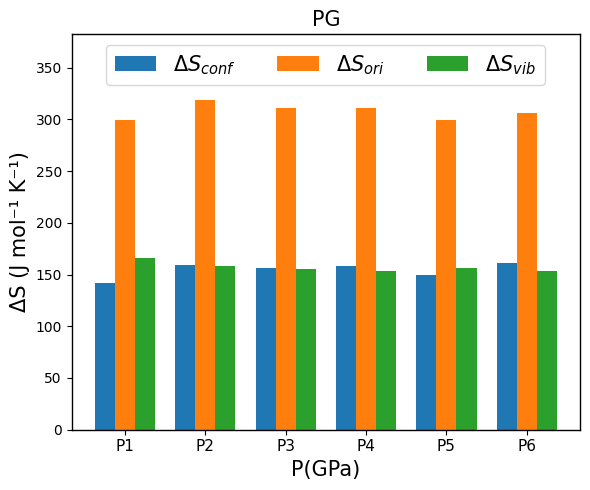

In [36]:
import numpy as np
import matplotlib.pyplot as plt

pressures = ['P1', 'P2', 'P3', 'P4', 'P5', 'P6']
x = np.arange(len(pressures))

ori  = [212.54, 202.48, 200.93, 202.63, 200.71, 198.60]
conf = [177.26, 153.21, 156.04, 171.46, 167.45, 163.80]
vib  = [255.94, 240.93, 238.59, 238.15, 236.62, 227.64]

ori  = [334.82, 321.97, 297.13, 270.23, 271.00, 233.53]
conf = [150.45, 149.34, 144.81, 129.00, 134.76, 111.03]
vib  = [ 90.00,  80.00,  83.36,  77.82,  66.36,  48.77]

ori  = [299.43, 318.44, 311.31, 311.09, 299.74, 306.51]
conf = [142.25, 159.08, 156.75, 158.43, 149.12, 160.99]
vib  = [165.96, 157.92, 155.66, 153.67, 156.67, 153.75]

width = 0.25
fig, ax = plt.subplots(figsize=(6, 5))

ekw = dict(ecolor='black', capsize=4, capthick=1.2, elinewidth=1.2)

ax.bar(x- width,         conf, width, color='#1f77b4', label=r'$\Delta S_{conf}$ ')
ax.bar(x, ori,  width, color='#ff7f0e', label=r'$\Delta S_{ori}$ ')
ax.bar(x + width, vib,  width, color='#2ca02c', label=r'$\Delta S_{vib}$ ')

ax.set_title('PG', fontsize=15)
ax.set_xlabel('P(GPa)', fontsize=15)
ax.set_ylabel('ΔS (J mol⁻¹ K⁻¹)', fontsize=15)
ax.set_xticks(x)
ax.set_xticklabels(pressures, fontsize=11)
ax.set_ylim(0, max(ori) * 1.2)

#ax.yaxis.grid(True, color='lightgray', linestyle='-', linewidth=0.8)
ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(1.0)

ax.legend(frameon=True, fontsize=15, ncols=3, loc='upper center')

plt.tight_layout()
#plt.savefig('entropia_plot.png', dpi=150, bbox_inches='tight')
plt.show()

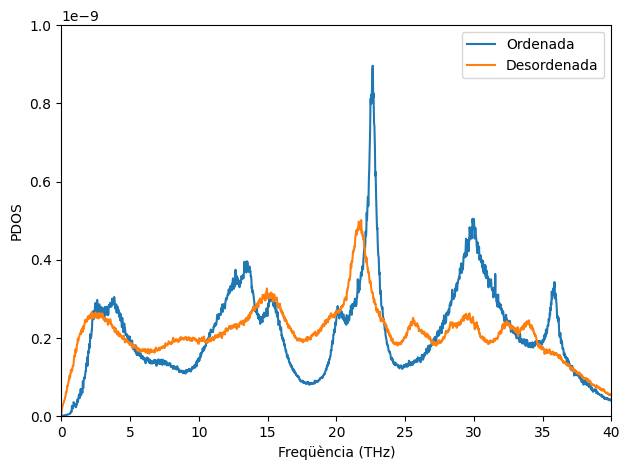

In [44]:
import numpy as np
import matplotlib.pyplot as plt

freq_ord, pdos_ord = np.loadtxt("/home/aressanuy/Desktop/doc/NPG/fitxesgrafics/pdos/pdos_PE_475.dat",    comments='#', unpack=True)
freq_dis, pdos_dis = np.loadtxt("/home/aressanuy/Desktop/doc/NPG/fitxesgrafics/pdos/pdos_PE_480.dat", comments='#', unpack=True)

freq_ord, pdos_ord = np.loadtxt("/home/aressanuy/Desktop/doc/NPG/fitxesgrafics/pdos/pdos_NPG_300.dat",    comments='#', unpack=True)
freq_dis, pdos_dis = np.loadtxt("/home/aressanuy/Desktop/doc/NPG/fitxesgrafics/pdos/pdos_NPG_305.dat", comments='#', unpack=True)

freq_ord, pdos_ord = np.loadtxt("/home/aressanuy/Desktop/doc/NPG/fitxesgrafics/pdos/pdos_PG_370.dat",    comments='#', unpack=True)
freq_dis, pdos_dis = np.loadtxt("/home/aressanuy/Desktop/doc/NPG/fitxesgrafics/pdos/pdos_PG_375.dat", comments='#', unpack=True)



#plt.figure(figsize=(10, 5))
plt.plot(freq_ord * 1e-12, pdos_ord, label='Ordenada')
plt.plot(freq_dis * 1e-12, pdos_dis, label='Desordenada')

plt.xlabel('Freqüència (THz)')
plt.xlim([0, 40])
plt.ylim([0, 1*1e-9])
plt.ylabel('PDOS')
plt.legend()
plt.tight_layout()
plt.savefig('pdos_plot.png', dpi=150)
plt.show()

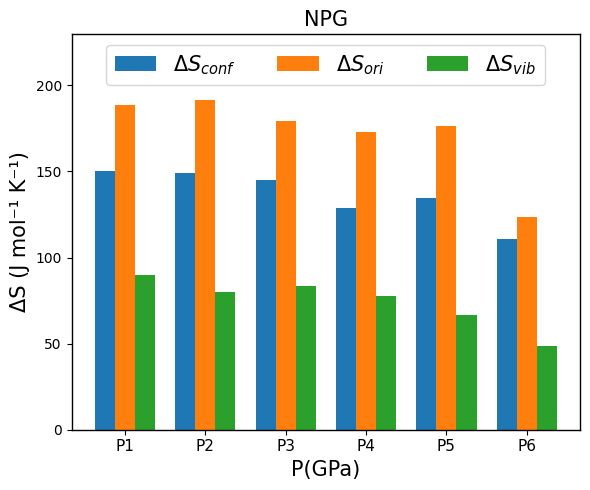

In [56]:
import numpy as np
import matplotlib.pyplot as plt

pressures = ['P1', 'P2', 'P3', 'P4', 'P5', 'P6']
x = np.arange(len(pressures))
# PE
ori  = [113.91, 129.13, 129.27,  94.27, 107.88, 117.99]
conf = [177.26, 153.21, 156.04, 171.46, 167.45, 163.80]
vib  = [255.94, 240.93, 238.59, 238.15, 236.62, 227.64]

# PG
ori  = [157.18, 159.36, 154.56, 154.77, 150.62, 145.52]
conf = [142.25, 159.08, 156.75, 159.25, 149.12, 161.00]
vib  = [165.96, 157.92, 155.66, 153.67, 156.67, 153.75]

# NPG
ori  = [188.37, 191.39, 179.09, 173.00, 176.70, 123.80]
conf = [150.45, 149.34, 144.81, 129.00, 134.76, 111.03]
vib  = [ 90.00,  80.00,  83.36,  77.82,  66.36,  48.77]



width = 0.25
fig, ax = plt.subplots(figsize=(6, 5))

ekw = dict(ecolor='black', capsize=4, capthick=1.2, elinewidth=1.2)

ax.bar(x- width,         conf, width, color='#1f77b4', label=r'$\Delta S_{conf}$ ')
ax.bar(x, ori,  width, color='#ff7f0e', label=r'$\Delta S_{ori}$ ')
ax.bar(x + width, vib,  width, color='#2ca02c', label=r'$\Delta S_{vib}$ ')

ax.set_title('NPG', fontsize=15)
ax.set_xlabel('P(GPa)', fontsize=15)
ax.set_ylabel('ΔS (J mol⁻¹ K⁻¹)', fontsize=15)
ax.set_xticks(x)
ax.set_xticklabels(pressures, fontsize=11)
ax.set_ylim(0, max(ori) * 1.2)

#ax.yaxis.grid(True, color='lightgray', linestyle='-', linewidth=0.8)
ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(1.0)

ax.legend(frameon=True, fontsize=15, ncols=3, loc='upper center')

plt.tight_layout()
#plt.savefig('entropia_plot.png', dpi=150, bbox_inches='tight')
plt.show()

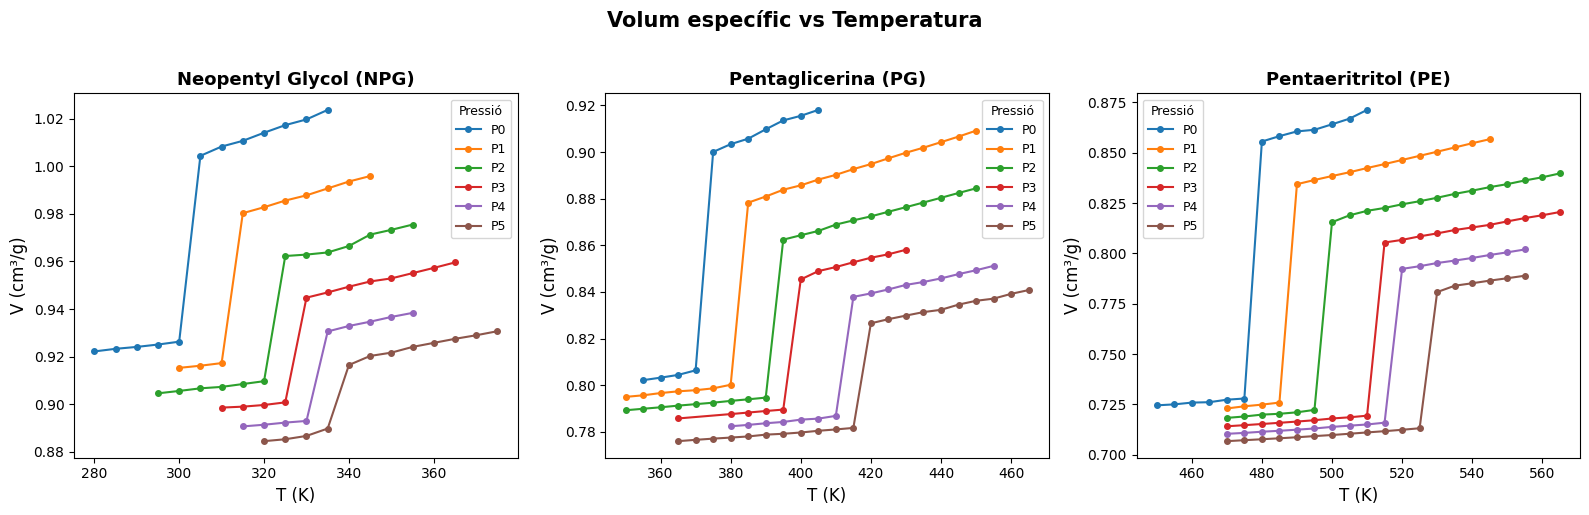

In [15]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import glob
import os

# Colors per pressió (igual que la imatge de referència)
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown']
materials = ['NPG', 'PG', 'PE']
titles    = ['Neopentyl Glycol (NPG)', 'Pentaglicerina (PG)', 'Pentaeritritol (PE)']

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)

for ax, material, title in zip(axes, materials, titles):
    files = sorted(glob.glob(f"/home/aressanuy/Desktop/doc/paper-npgpgpe/f_volum/P*_{material}.dat"))
    
    if not files:
        ax.text(0.5, 0.5, f'No hi ha dades\nper {material}',
                ha='center', va='center', transform=ax.transAxes, fontsize=12)
        ax.set_title(title, fontsize=13, fontweight='bold')
        continue

    for i, fpath in enumerate(files):
        label = os.path.basename(fpath).split('_')[0]  # P0, P1, ...
        try:
            data = np.loadtxt(fpath, comments='#')
            if data.ndim == 1:
                data = data[np.newaxis, :]
            T = data[:, 0]
            if material == 'PE':
                V = data[:, 1]*0.0043
            if material == 'NPG':
                V = data[:, 1]
            if material == 'PG':
                V = data[:, 1]*0.0098

            ax.plot(T, V, 'o-', color=colors[i % len(colors)],
                    label=label, linewidth=1.5, markersize=4)
        except Exception as e:
            print(f"  Error llegint {fpath}: {e}")

    ax.set_xlabel('T (K)', fontsize=12)
    ax.set_ylabel('V (cm³/g)', fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(title='Pressió', fontsize=9, title_fontsize=9)
    #ax.grid(True, alpha=0.3)

plt.suptitle('Volum específic vs Temperatura', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
#plt.savefig('VvsT_3materials.png', dpi=150, bbox_inches='tight')
#print("Plot guardat: VvsT_3materials.png")

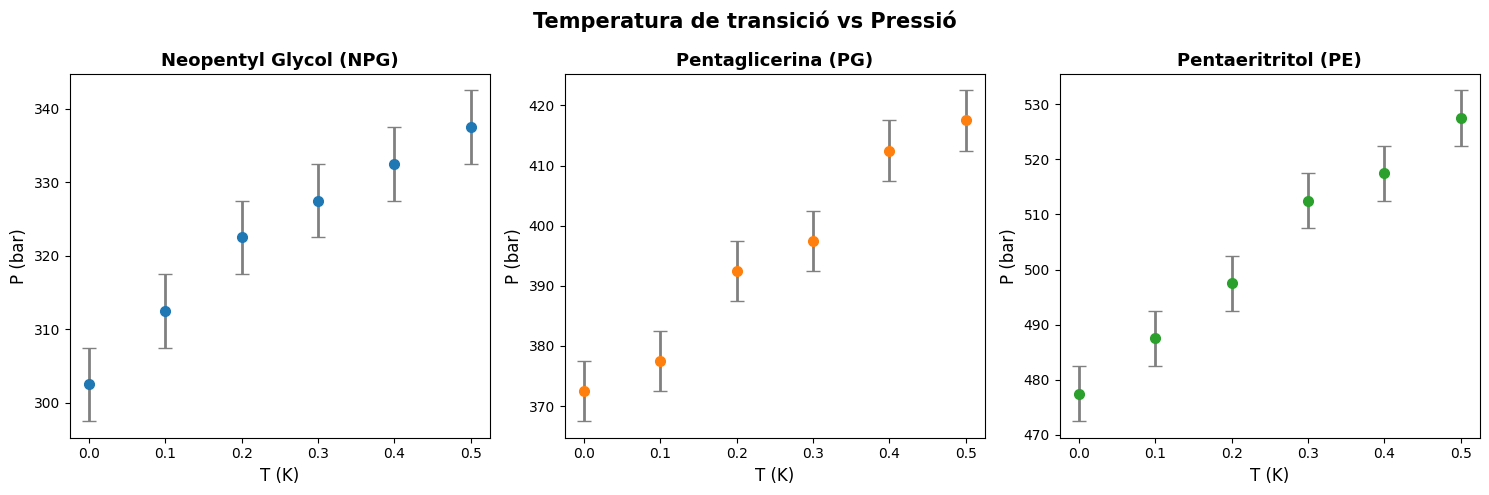

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# Dades de transició: T (K) per cada pressió (bar)
P = [0, 0.1, 0.2,0.3, 0.4, 0.5]  # en bar

data = {
    'NPG': [302.5, 312.5, 322.5, 327.5, 332.5, 337.5],  # mitjana dels dos T per cada P
    'PG':  [372.5, 377.5, 392.5, 397.5, 412.5, 417.5],
    'PE':  [477.5, 487.5, 497.5, 512.5, 517.5, 527.5],
}

titles = {
    'NPG': 'Neopentyl Glycol (NPG)',
    'PG':  'Pentaglicerina (PG)',
    'PE':  'Pentaeritritol (PE)',
}

colors = {
    'NPG': 'tab:blue',
    'PG':  'tab:orange',
    'PE':  'tab:green',
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)

for ax, material in zip(axes, ['NPG', 'PG', 'PE']):
    T_trans = data[material]
    ax.errorbar(P, T_trans, yerr=5, fmt='o', color=colors[material],
                ecolor='gray', capsize=5, linewidth=2, markersize=7)
    ax.set_xlabel('T (K)', fontsize=12)
    ax.set_ylabel('P (bar)', fontsize=12)
    ax.set_title(titles[material], fontsize=13, fontweight='bold')
    #ax.grid(True, alpha=0.3)
    # Anotació de cada punt

plt.suptitle('Temperatura de transició vs Pressió', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

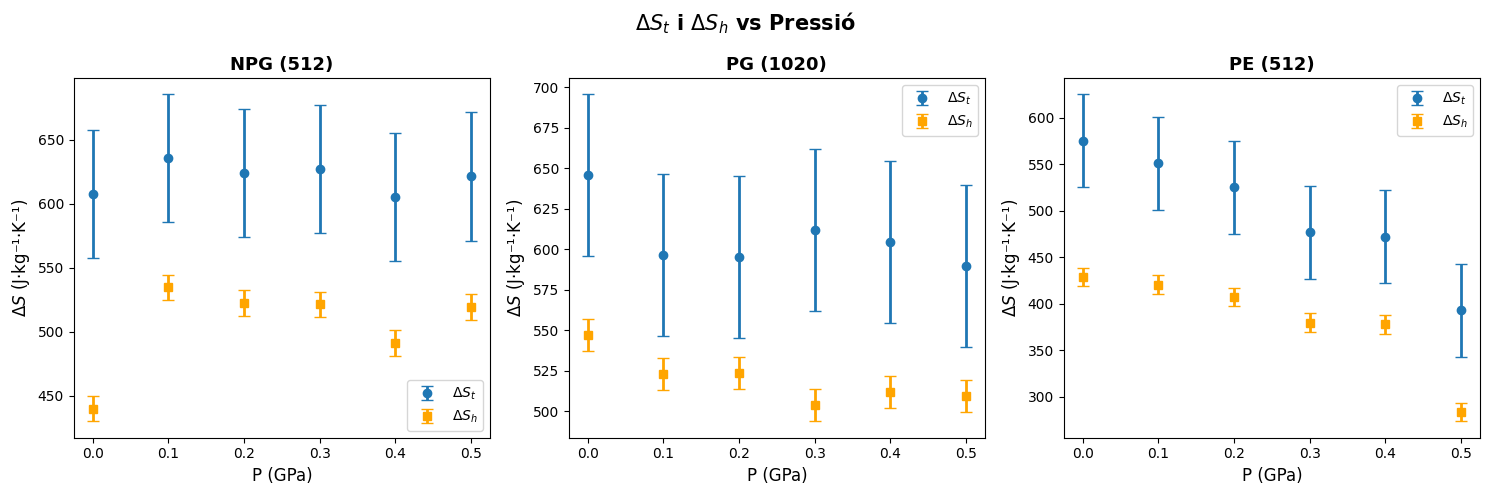

In [27]:
import numpy as np
import matplotlib.pyplot as plt

P = [0, 0.1, 0.2, 0.3, 0.4, 0.5]  # GPa

data = {
    'NPG (512)': {
        'Ast': [607.63, 635.44, 623.72, 626.94, 605.52, 621.26],
        'Ash': [440.10, 534.65, 522.35, 521.35, 491.08, 519.20],
    },
    'PG (1020)': {
        'Ast': [645.74, 596.62, 595.56, 612.24, 604.79, 590.04],
        'Ash': [547.11, 523.27, 523.90, 503.88, 511.95, 509.43],
    },
    'PE (512)': {
        'Ast': [575.27, 551.31, 525.30, 477.05, 472.12, 393.33],
        'Ash': [428.82, 420.73, 407.26, 379.82, 377.82, 283.60],
    },
}

colors_t = {'NPG (512)': 'tab:blue',   'PG (1020)': 'tab:blue', 'PE (512)': 'tab:blue'}
colors_h = {'NPG (512)': 'orange',  'PG (1020)': 'orange', 'PE (512)': 'orange'}

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)

for ax, (material, vals) in zip(axes, data.items()):
    ax.errorbar(P, vals['Ast'], yerr=50, fmt='o', color=colors_t[material],
                ecolor=colors_t[material], capsize=4, linewidth=2, markersize=6, label=r'$\Delta S_t$')
    ax.errorbar(P, vals['Ash'], yerr=10, fmt='s', color=colors_h[material],
                ecolor=colors_h[material], capsize=4, linewidth=2, markersize=6, label=r'$\Delta S_h$')
    ax.set_xlabel('P (GPa)', fontsize=12)
    ax.set_ylabel(r'$\Delta S$ (J·kg⁻¹·K⁻¹)', fontsize=12)
    ax.set_title(material, fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    #ax.grid(True, alpha=0.3)

plt.suptitle(r'$\Delta S_t$ i $\Delta S_h$ vs Pressió', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()